<a href="https://colab.research.google.com/github/emilsar/Cedars/blob/main/Project3/Pre_1_load_data_operations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Image Basics

###Creating the Image

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import filters, morphology, exposure  # Add this line

# Create 10x10 grayscale image with values [0, 1]
image = np.array([
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    [1.0, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.4, 0.4, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.0, 0.1, 0.2, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.0, 0.0, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.4, 0.4, 0.3, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.5, 0.8, 1.0],
    [1.0, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.0],
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
], dtype=np.float32)

print("Image values (float in [0,1]):")
print(image)
print(f"\nShape: {image.shape}")
print(f"Data Type it Contains: {image.dtype}")
print(f"Type of Object: {type(image)}")
print(f"Range: [{image.min()}, {image.max()}]")

Image values (float in [0,1]):
[[1.  1.  1.  1.  1.  1.  1.  1.  1.  1. ]
 [1.  0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 1. ]
 [1.  0.8 0.6 0.6 0.6 0.6 0.6 0.6 0.8 1. ]
 [1.  0.8 0.6 0.4 0.4 0.4 0.4 0.6 0.8 1. ]
 [1.  0.8 0.6 0.4 0.  0.1 0.2 0.6 0.8 1. ]
 [1.  0.8 0.6 0.4 0.  0.  0.4 0.6 0.8 1. ]
 [1.  0.8 0.6 0.4 0.4 0.4 0.3 0.6 0.8 1. ]
 [1.  0.8 0.6 0.6 0.6 0.6 0.6 0.5 0.8 1. ]
 [1.  0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 1. ]
 [1.  1.  1.  1.  1.  1.  1.  1.  1.  1. ]]

Shape: (10, 10)
Data Type it Contains: float32
Type of Object: <class 'numpy.ndarray'>
Range: [0.0, 1.0]


###Displaying Image and Interpolations

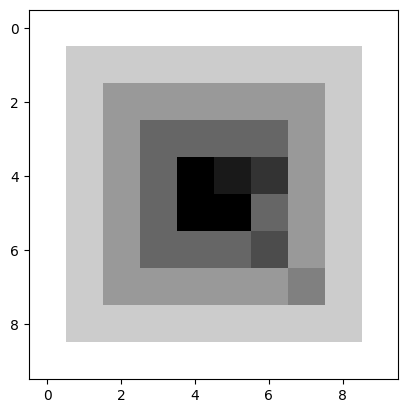

In [6]:
#plt.figure(figsize=(3, 3))
plt.imshow(image, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
#plt.colorbar(label='Intensity [0,1]')
#plt.title("10x10 Grayscale Image (float [0,1])")
#plt.show()

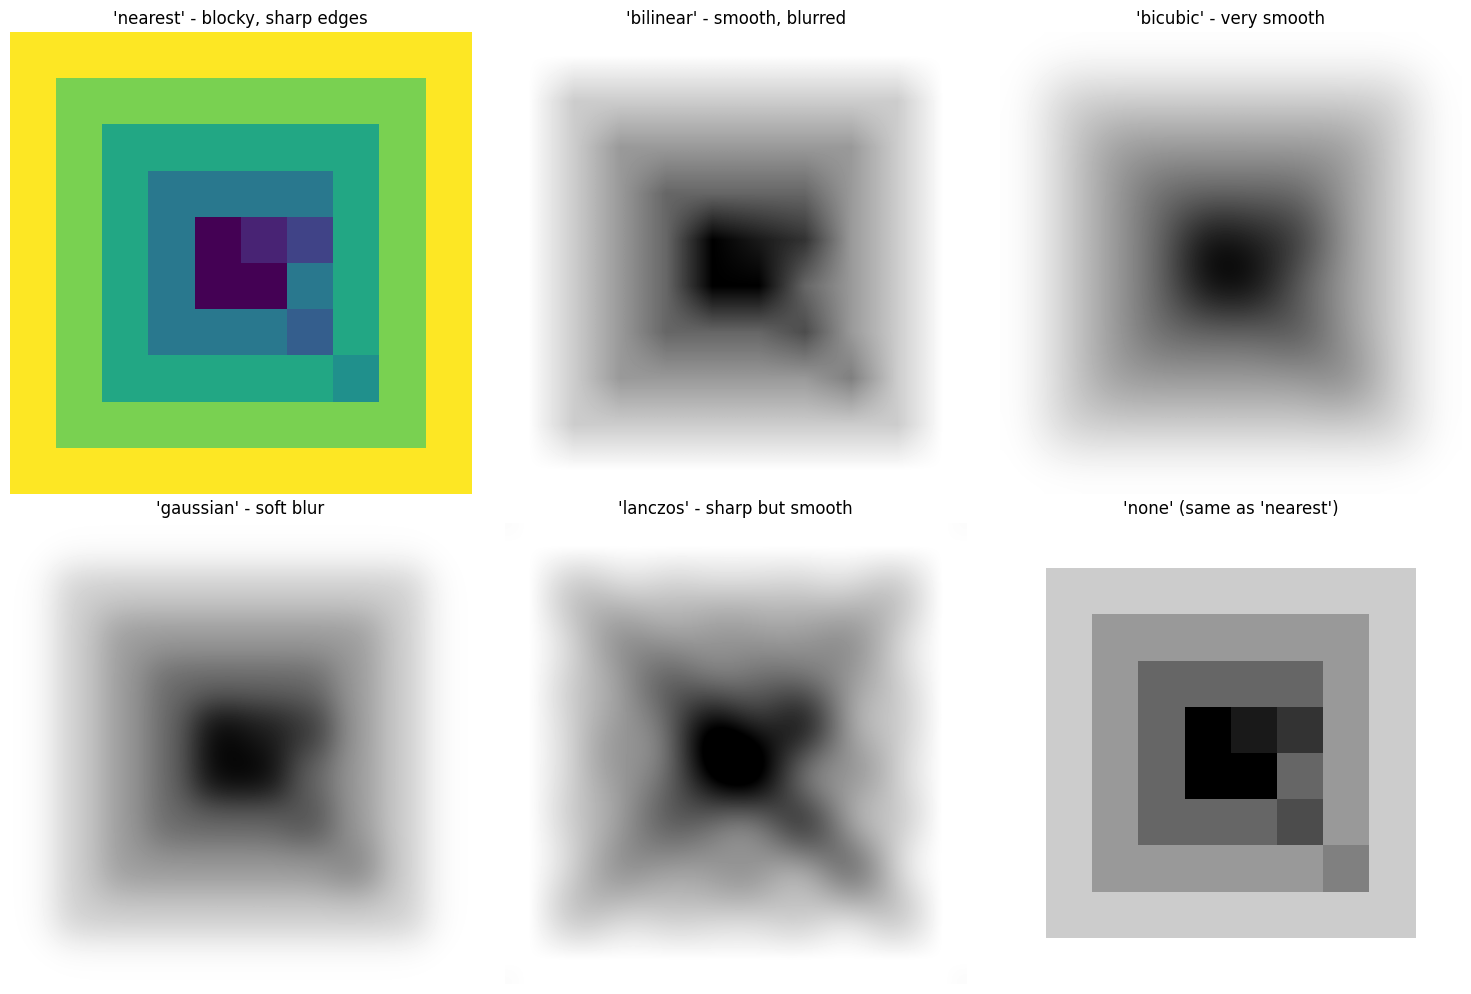

In [16]:
# Compare different interpolations
#https://en.wikipedia.org/wiki/Bicubic_interpolation#/media/File:Comparison_of_1D_and_2D_interpolation.svg
#On Gaussian Blur:  https://www.youtube.com/watch?v=C_zFhWdM4ic&t=229s
#On Lanczos:  https://mazzo.li/posts/lanczos.html


fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(image, cmap='viridis', interpolation='nearest')
axes[0, 0].set_title("'nearest' - blocky, sharp edges")
axes[0, 0].axis('off')

axes[0, 1].imshow(image, cmap='gray', interpolation='bilinear')
axes[0, 1].set_title("'bilinear' - smooth, blurred")
axes[0, 1].axis('off')

axes[0, 2].imshow(image, cmap='gray', interpolation='bicubic')
axes[0, 2].set_title("'bicubic' - very smooth")
axes[0, 2].axis('off')

axes[1, 0].imshow(image, cmap='gray', interpolation='gaussian')
axes[1, 0].set_title("'gaussian' - soft blur")
axes[1, 0].axis('off')

axes[1, 1].imshow(image, cmap='gray', interpolation='lanczos')
axes[1, 1].set_title("'lanczos' - sharp but smooth")
axes[1, 1].axis('off')

axes[1, 2].imshow(image, cmap='gray', interpolation='none')
axes[1, 2].set_title("'none' (same as 'nearest')")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

Matplotlib provides many built-in colormaps, categorized as follows:

*   **Perceptually Uniform Sequential:** These colormaps are designed to have an evenly changing luminance (brightness) throughout their range. They are good for representing data where continuity and order are important.
    *   `viridis`, `plasma`, `inferno`, `magma`, `cividis`, `twilight`, `twilight_shifted`, `turbo`

*   **Sequential:** These colormaps are also for ordered data, often representing quantities from low to high. They may not be perceptually uniform.
    *   `Greys`, `Purples`, `Blues`, `Greens`, `Oranges`, `Reds`
    *   `YlOrBr`, `YlOrRd`, `OrRd`, `PuBuGn`, `PuBu`, `GnBu`, `BuGn`, `YlGnBu`, `YlGn`

*   **Sequential (2):** Another set of sequential colormaps, often with a slightly different aesthetic.
    *   `binary`, `gist_yarg`, `gist_gray`, `gray`, `bone`, `pink`, `spring`, `summer`, `autumn`, `winter`, `cool`, `Wistia`, `hot`, `afmhot`, `gist_heat`, `copper`

*   **Diverging:** These colormaps are used when data has a meaningful mid-point (e.g., zero) and diverges in two directions (e.g., positive/negative, above/below average).
    *   `PiYG`, `PRGn`, `BrBG`, `PuOr`, `RdGy`, `RdBu`, `RdYlBu`, `RdYlGn`, `Spectral`, `coolwarm`, `bwr`, `seismic`

*   **Cyclic:** These colormaps are for data that wraps around, like phase angles or directions.
    *   `twilight`, `twilight_shifted`, `hsv`

*   **Qualitative:** Used for discrete categories, where no ordering or relationship between categories is implied.
    *   `Pastel1`, `Pastel2`, `Paired`, `Accent`, `Dark2`, `Set1`, `Set2`, `Set3`, `tab10`, `tab20`, `tab20b`, `tab20c`

*   **Miscellaneous:** Other colormaps that don't fit neatly into the above categories.
    *   `flag`, `prism`, `ocean`, `gist_earth`, `terrain`, `gist_stern`, `gnuplot`, `gnuplot2`, `CMRmap`, `cubehelix`, `brg`, `gist_rainbow`, `rainbow`, `jet`, `nipy_spectral`, `gist_ncar`

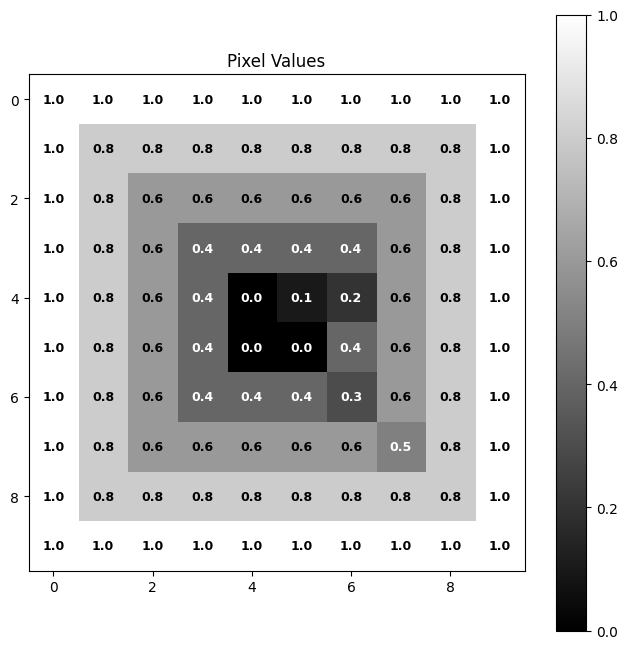

In [ ]:
# Display with numerical values
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
for i in range(10):
    for j in range(10):
        color = "black" if image[i, j] > 0.5 else "white"
        ax.text(j, i, f'{image[i, j]:.1f}',
               ha="center", va="center",
               color=color, fontsize=9, weight='bold')
ax.set_title("Pixel Values")
plt.colorbar(ax.imshow(image, cmap='gray', interpolation='nearest', vmin=0, vmax=1))
plt.show()

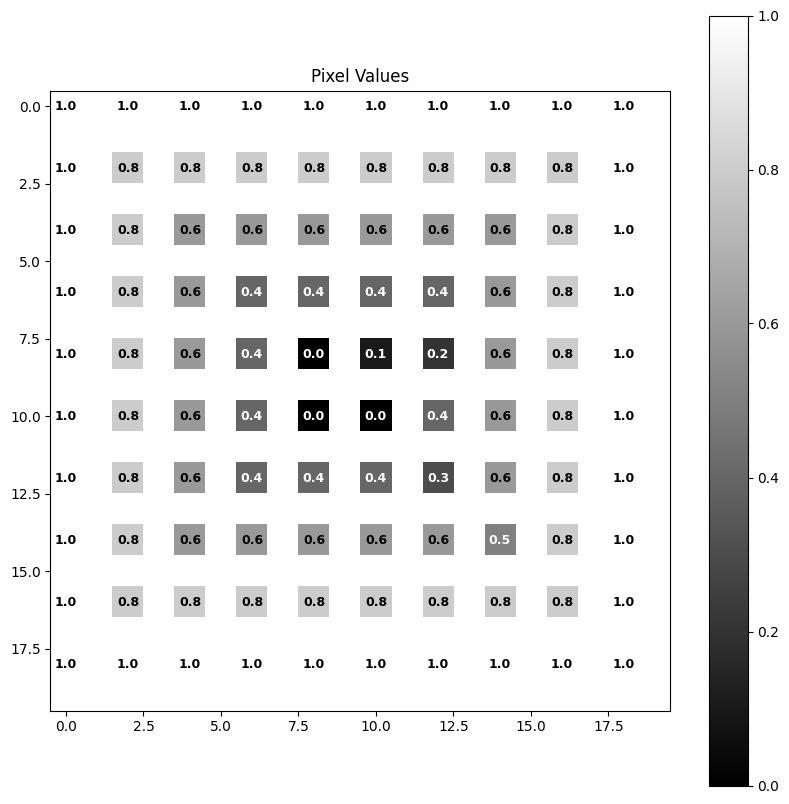

In [23]:
# Create 20x20 sparse grid
scale_factor = 2
sparse = np.full((20, 20), np.nan, dtype=np.float32)

for i in range(10):
    for j in range(10):
        sparse[i*scale_factor, j*scale_factor] = image[i, j]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(sparse, cmap='gray', vmin=0, vmax=1, interpolation='nearest')

for i in range(10):
    for j in range(10):
        value = image[i, j]
        color = "black" if value > 0.5 else "white"
        pos_i = i * scale_factor
        pos_j = j * scale_factor
        ax.text(pos_j, pos_i, f'{value:.1f}',
               ha="center", va="center",
               color=color, fontsize=9, weight='bold')

ax.set_title("Pixel Values")
plt.colorbar(ax.images[0], ax=ax)
plt.show()

###Committing to Github

In [ ]:
!git clone https://emilsar:@github.com/emilsar/Cedars.git


Cloning into 'Cedars'...
remote: Enumerating objects: 1133, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 1133 (delta 22), reused 4 (delta 0), pack-reused 1088 (from 2)
Receiving objects: 100% (1133/1133), 1.22 GiB | 29.90 MiB/s, done.
Resolving deltas: 100% (399/399), done.
Updating files: 100% (893/893), done.


In [ ]:
%cd Cedars/Project3/
%ls

/content/Cedars/Project3
 0_package_installs.ipynb        final_thresholds.pkl
 1_load_data_operations.ipynb    imagedata/
 1_prepdata.py                   Project3_Description.md
 2_Intensity_Approach.ipynb      __pycache__/
 3_Feature_Extraction.ipynb      QuPath_Examples/
 4_KMeans_RF.ipynb               QuPath_Examples.zip
 5_DL_image_segmentation.ipynb  'SAM protocol.docx'
 cell_images/                    seg_models/
 deprecated/                     semseg_functions.py
 DL_result_imgs/                 specimens_toy_data.pkl
 feature_extraction_utils.py


In [ ]:
np.save("artificial_cell",image)
!git add artificial_cell.npy
!git commit -m "Add cell image"
# Update the remote URL to include your token
#!git remote set-url origin https://emilsar@github.com/emilsar/Cedars.git
!git config --global user.email "emilsar@github.com"
!git config --global user.name "emilsar"

# Now regular push works
!git push

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 456 bytes | 456.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/emilsar/Cedars.git
   42e356f..beaaa9c  main -> main


###Image Statistics

In [ ]:
print (image[:][2])
print (np.mean(image[:][2]))

[1.  0.8 0.6 0.6 0.6 0.6 0.6 0.6 0.8 1. ]
0.72


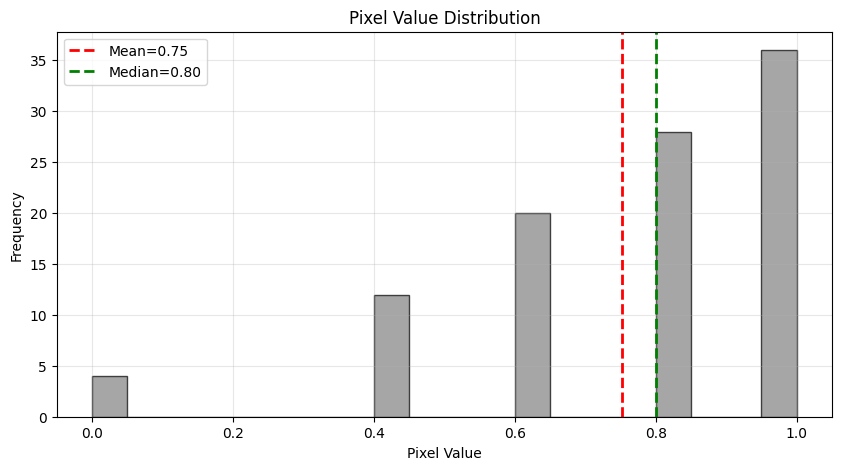

In [ ]:
# Histogram
plt.figure(figsize=(10, 5))
plt.hist(image.flatten(), bins=20, color='gray', alpha=0.7, edgecolor='black')
plt.axvline(image.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean={image.mean():.2f}')
plt.axvline(np.median(image), color='g', linestyle='--', linewidth=2, label=f'Median={np.median(image):.2f}')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Pixel Value Distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#4D NP Tensors, & Dictionaries

## Defining, and Manipulating 4D Tensors

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# Create a batch of 10 synthetic images
images_4d = np.random.rand(2, 3, 4, 4)
print(f"Shape: {images_4d.shape}")
print(images_4d)
print(f"Number of images: {images_4d.shape[0]}")
print(f"Channels per image: {images_4d.shape[1]}")
print(f"Image dimensions: {images_4d.shape[2]} × {images_4d.shape[3]}")

Shape: (2, 3, 4, 4)
[[[[0.1708011  0.3692062  0.05269824 0.40807518]
   [0.09051557 0.86925039 0.5554555  0.09418071]
   [0.07765997 0.37856999 0.10043188 0.67178674]
   [0.05794928 0.61954953 0.60362878 0.28977876]]

  [[0.86781477 0.18529158 0.47228892 0.70288501]
   [0.21047115 0.24694069 0.16595263 0.92216327]
   [0.47403276 0.08804565 0.38633411 0.35900412]
   [0.18964132 0.89051645 0.53404299 0.21230811]]

  [[0.67041829 0.72710998 0.73810836 0.67202101]
   [0.00819966 0.42572572 0.65878265 0.99562653]
   [0.83490919 0.94506745 0.8844414  0.17474451]
   [0.98833292 0.5976393  0.25109381 0.61272743]]]


 [[[0.47810657 0.64891172 0.15842976 0.09305273]
   [0.03353537 0.44551608 0.25974381 0.84162712]
   [0.75608672 0.45338768 0.83144107 0.26750495]
   [0.60015569 0.80988934 0.83123872 0.20949469]]

  [[0.01338003 0.5022977  0.73329575 0.9807978 ]
   [0.71717383 0.61290678 0.36462222 0.70052154]
   [0.6637344  0.27398857 0.1282151  0.53260512]
   [0.13146882 0.07077915 0.18165553 0.

In [12]:
# Access first image (returns 3D tensor)
first_image = images_4d[0]
print(f"First image shape: {first_image.shape}")  # Shape: (3, 256, 256)

# Access red channel of all images
all_red_channels = images_4d[:, 0, :, :]
print(f"All red Channels:{all_red_channels}")
print(f"All red channels shape: {all_red_channels.shape}")  # Shape: (10, 256, 256)

# Access center pixel of all images, all channels
center_pixels = images_4d[:, :, 2, 2]
print(f"Center pixels shape: {center_pixels.shape}")  # Shape: (10, 3)
print(f"Center pixel RGB values for first image: {center_pixels[0]}")

# Access subset of batch
first_five = images_4d[0:3]
print(f"First five images shape: {first_five.shape}")  # Shape: (5, 3, 256, 256)

First image shape: (3, 4, 4)
All red Channels:[[[0.1708011  0.3692062  0.05269824 0.40807518]
  [0.09051557 0.86925039 0.5554555  0.09418071]
  [0.07765997 0.37856999 0.10043188 0.67178674]
  [0.05794928 0.61954953 0.60362878 0.28977876]]

 [[0.47810657 0.64891172 0.15842976 0.09305273]
  [0.03353537 0.44551608 0.25974381 0.84162712]
  [0.75608672 0.45338768 0.83144107 0.26750495]
  [0.60015569 0.80988934 0.83123872 0.20949469]]]
All red channels shape: (2, 4, 4)
Center pixels shape: (2, 3)
Center pixel RGB values for first image: [0.10043188 0.38633411 0.8844414 ]
First five images shape: (2, 3, 4, 4)


##Statistical Operations with Tensors

#Thresholding

###Manual Threshold

In [ ]:
threshold_simple=0.5
binary_simple = (image < threshold_simple).astype(np.float32)
print(f"Threshold value: {threshold_simple}")
print(f"Logic: pixel < {threshold_simple} → nucleus (1), else → background (0)")
print(f"Nucleus pixels detected: {binary_simple.sum():.0f} out of {binary_simple.size}")
print(f"Percentage of image: {100 * binary_simple.sum() / binary_simple.size:.1f}%")
print(binary_simple)



Threshold value: 0.5
Logic: pixel < 0.5 → nucleus (1), else → background (0)
Nucleus pixels detected: 16 out of 100
Percentage of image: 16.0%
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


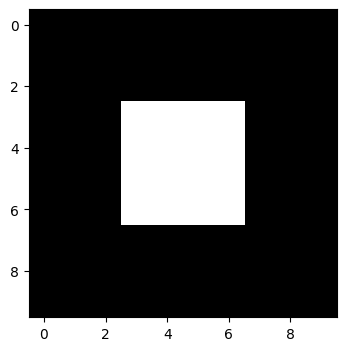

In [ ]:
# Visualize Manual Threshold
plt.figure(figsize=(4, 4))
plt.imshow(binary_simple, cmap='gray', interpolation='nearest')
#plt.title("Manual Threshold Result")
#plt.axis('off')
plt.show()

###Otsu's Automatic Threshold

[[255 255 255 255 255 255 255 255 255 255]
 [255 204 204 204 204 204 204 204 204 255]
 [255 204 153 153 153 153 153 153 204 255]
 [255 204 153 102 102 102 102 153 204 255]
 [255 204 153 102   0  25  51 153 204 255]
 [255 204 153 102   0   0 102 153 204 255]
 [255 204 153 102 102 102  76 153 204 255]
 [255 204 153 153 153 153 153 127 204 255]
 [255 204 204 204 204 204 204 204 204 255]
 [255 255 255 255 255 255 255 255 255 255]]
0.6
Otsu threshold (automatic): 0.600
Nucleus pixels detected: 17 out of 100
Percentage of image: 17.0%



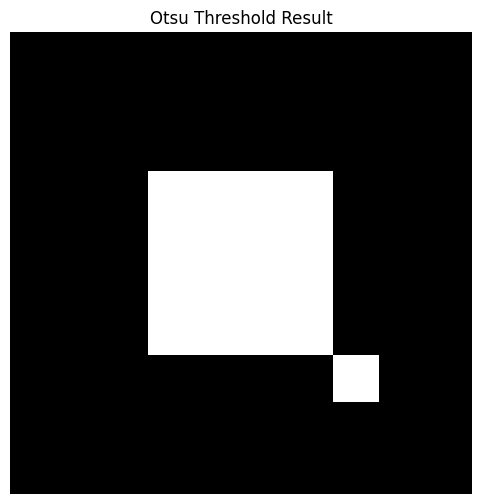

In [ ]:
# Otsu's method automatically finds optimal threshold
# How? Minimizes within-class variance (maximizes separation between classes)
# Assumes bimodal histogram (two peaks: dark nucleus, bright background)

# Convert to uint8 for Otsu (it expects integer values)
image_uint8 = (image * 255).astype(np.uint8)
print (image_uint8)

# Compute Otsu threshold
threshold_otsu = filters.threshold_otsu(image_uint8) / 255.0
print(threshold_otsu)

# Create binary mask
binary_otsu = (image < threshold_otsu).astype(np.float32)

print(f"Otsu threshold (automatic): {threshold_otsu:.3f}")
print(f"Nucleus pixels detected: {binary_otsu.sum():.0f} out of {binary_otsu.size}")
print(f"Percentage of image: {100 * binary_otsu.sum() / binary_otsu.size:.1f}%")
print()

# PROS: Automatic, adaptive to image content, optimal for bimodal histograms
# CONS: Assumes two classes, fails with complex histograms

# Visualize Otsu Result
plt.figure(figsize=(6, 6))
plt.imshow(binary_otsu, cmap='gray', interpolation='nearest')
plt.title("Otsu Threshold Result")
plt.axis('off')
plt.show()


#Morphological Operations

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 255 255 255 255   0   0   0]
 [  0   0   0 255 255 255 255   0   0   0]
 [  0   0   0 255 255 255 255   0   0   0]
 [  0   0   0 255 255 255 255   0   0   0]
 [  0   0   0   0   0   0   0 255   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]]
Erosion:  shrinks white regions
Dilation: expands white regions
Opening:  erosion then dilation (removes small objects)
Closing:  dilation then erosion (fills small holes)


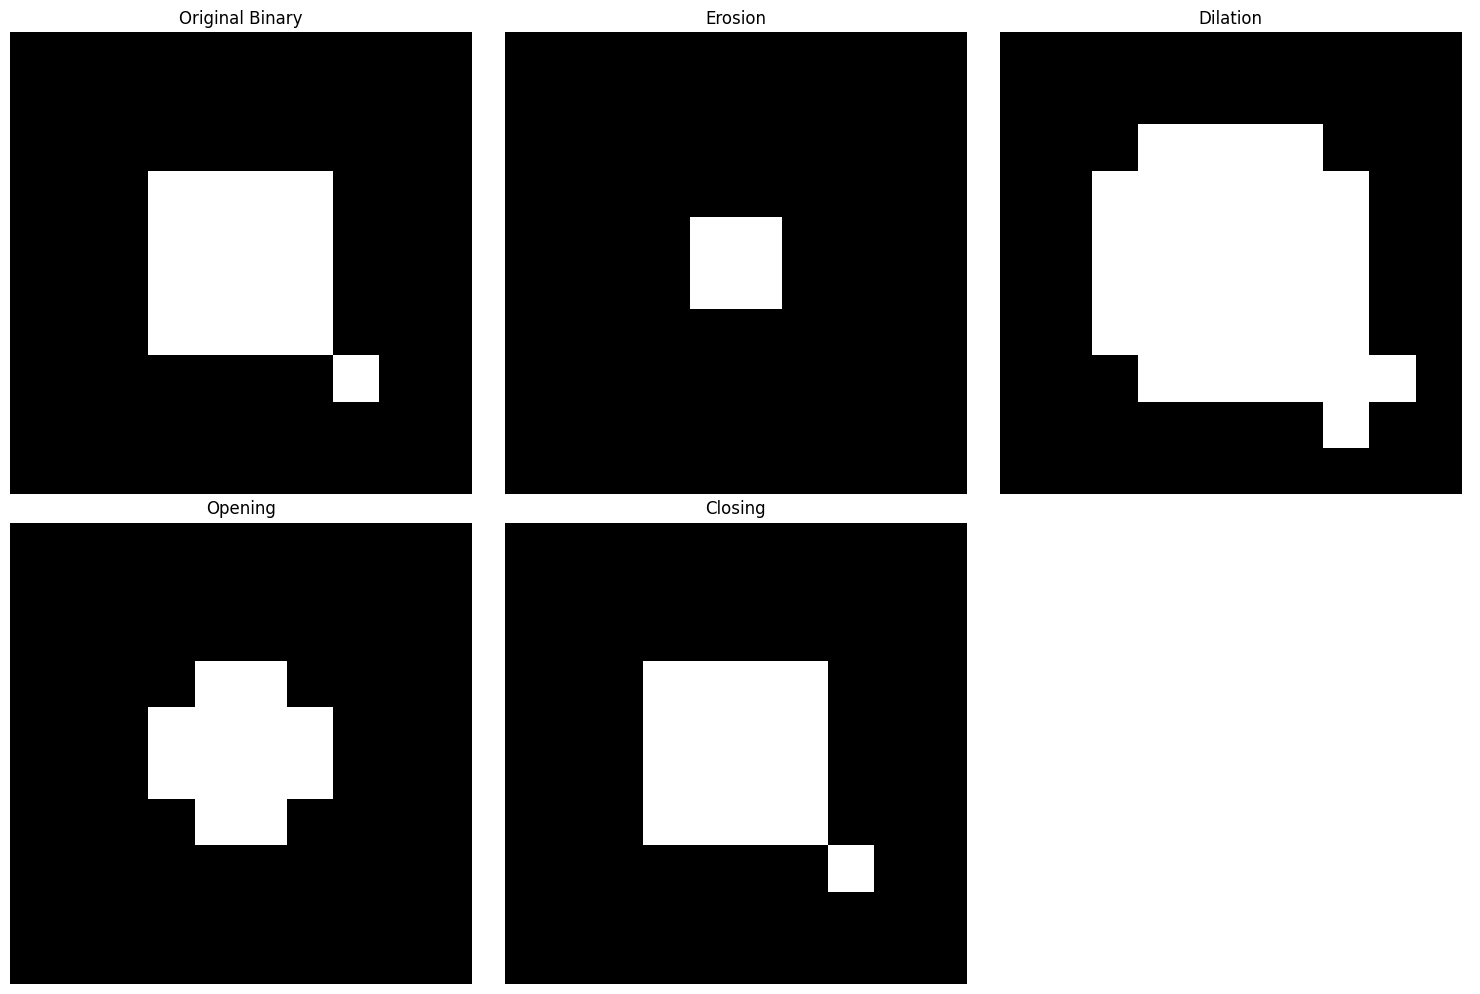

In [ ]:
# Convert to binary uint8 for morphology
binary_uint8 = (binary_otsu * 255).astype(np.uint8)
print(binary_simple)
print(binary_uint8)
# Morphological operations with small structuring element
selem = morphology.disk(1)

eroded = morphology.erosion(binary_uint8, selem)
dilated = morphology.dilation(binary_uint8, selem)
opened = morphology.opening(binary_uint8, selem)
closed = morphology.closing(binary_uint8, selem)

print("Erosion:  shrinks white regions")
print("Dilation: expands white regions")
print("Opening:  erosion then dilation (removes small objects)")
print("Closing:  dilation then erosion (fills small holes)")

# Convert back to float [0,1] for display
eroded = eroded.astype(np.float32) / 255.0
dilated = dilated.astype(np.float32) / 255.0
opened = opened.astype(np.float32) / 255.0
closed = closed.astype(np.float32) / 255.0

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(binary_otsu, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
axes[0, 0].set_title("Original Binary")
axes[0, 0].axis('off')

axes[0, 1].imshow(eroded, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
axes[0, 1].set_title("Erosion")
axes[0, 1].axis('off')

axes[0, 2].imshow(dilated, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
axes[0, 2].set_title("Dilation")
axes[0, 2].axis('off')

axes[1, 0].imshow(opened, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
axes[1, 0].set_title("Opening")
axes[1, 0].axis('off')

axes[1, 1].imshow(closed, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
axes[1, 1].set_title("Closing")
axes[1, 1].axis('off')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


#RGB Images

RGB image shape: (10, 10, 3)
RGB image dtype: float32
RGB image range: [0.0, 1.0]


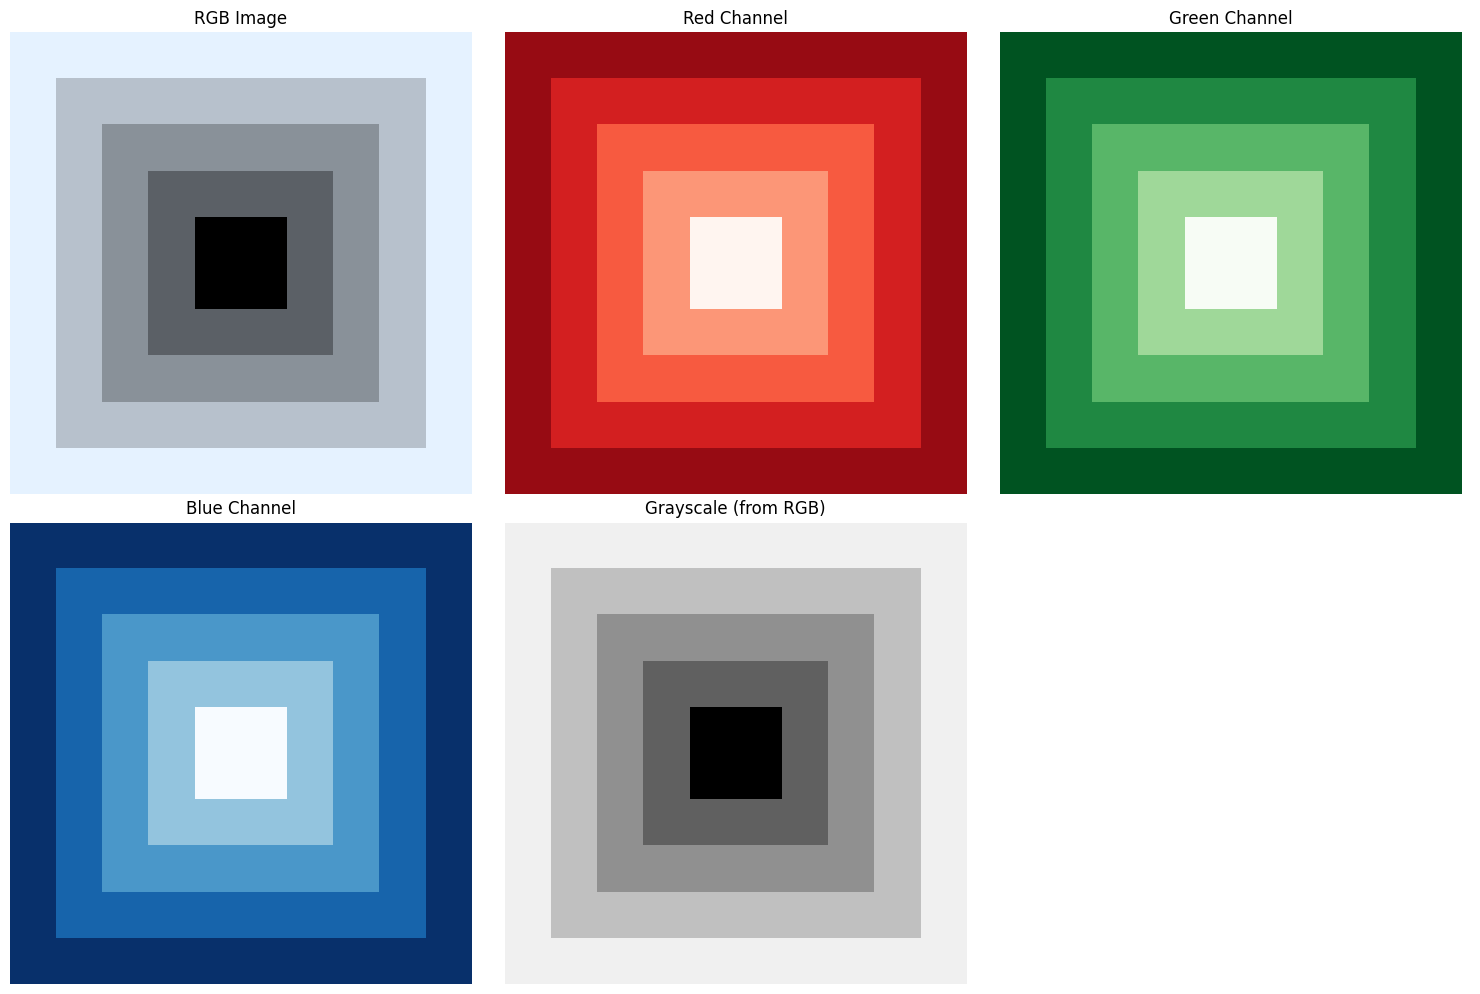

In [ ]:
# Create RGB version of cell image
rgb_image = np.zeros((10, 10, 3), dtype=np.float32)

# Use grayscale pattern with slight color tint
gray_pattern = np.array([
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    [1.0, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.4, 0.4, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.0, 0.0, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.0, 0.0, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.4, 0.4, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.0],
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
], dtype=np.float32)

rgb_image[:, :, 0] = gray_pattern * 0.9   # Red
rgb_image[:, :, 1] = gray_pattern * 0.95  # Green
rgb_image[:, :, 2] = gray_pattern * 1.0   # Blue (slight blue tint)

print(f"RGB image shape: {rgb_image.shape}")
print(f"RGB image dtype: {rgb_image.dtype}")
print(f"RGB image range: [{rgb_image.min()}, {rgb_image.max()}]")

# Extract channels
red_channel = rgb_image[:, :, 0]
green_channel = rgb_image[:, :, 1]
blue_channel = rgb_image[:, :, 2]

# Convert to grayscale using luminosity weights
gray_from_rgb = 0.299 * red_channel + 0.587 * green_channel + 0.114 * blue_channel

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(rgb_image, interpolation='nearest')
axes[0, 0].set_title("RGB Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(red_channel, cmap='Reds', interpolation='nearest', vmin=0, vmax=1)
axes[0, 1].set_title("Red Channel")
axes[0, 1].axis('off')

axes[0, 2].imshow(green_channel, cmap='Greens', interpolation='nearest', vmin=0, vmax=1)
axes[0, 2].set_title("Green Channel")
axes[0, 2].axis('off')

axes[1, 0].imshow(blue_channel, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
axes[1, 0].set_title("Blue Channel")
axes[1, 0].axis('off')

axes[1, 1].imshow(gray_from_rgb, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
axes[1, 1].set_title("Grayscale (from RGB)")
axes[1, 1].axis('off')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


#Connected Component Analysis



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage


##SECTION 1: CREATE A SIMPLE ARTIFICIAL CELL IMAGE (100x100)


Cell 1: Center (25, 25), radius 12 pixels, intensity 0.8
Cell 2: Center (25, 75), radius 10 pixels, intensity 0.8
Cell 3: Center (75, 50), radius 11 pixels, intensity 0.8

Image properties:
  Shape: (100, 100)
  Value range: [0.000, 0.800]
  Background value: 0.0 (black)
  Cell value: 0.8 (bright gray)
  Non-zero pixels: 1115


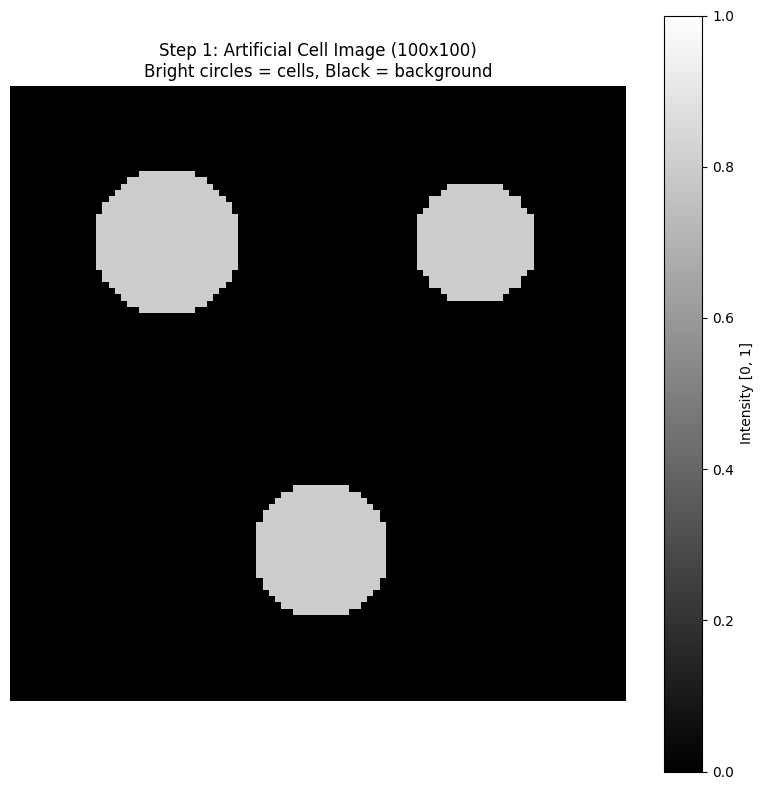

In [ ]:
# Create a 100x100 image filled with background (value = 0.0)
image = np.zeros((100, 100), dtype=np.float32)

# Cell 1: Bright circle in top-left area
print("\nCell 1: Center (25, 25), radius 12 pixels, intensity 0.8")
for row in range(100):
    for col in range(100):
        distance = np.sqrt((row - 25)**2 + (col - 25)**2)
        if distance < 12:
            image[row, col] = 0.8

# Cell 2: Bright circle in top-right area
print("Cell 2: Center (25, 75), radius 10 pixels, intensity 0.8")
for row in range(100):
    for col in range(100):
        distance = np.sqrt((row - 25)**2 + (col - 75)**2)
        if distance < 10:
            image[row, col] = 0.8

# Cell 3: Bright circle in bottom-center area
print("Cell 3: Center (75, 50), radius 11 pixels, intensity 0.8")
for row in range(100):
    for col in range(100):
        distance = np.sqrt((row - 75)**2 + (col - 50)**2)
        if distance < 11:
            image[row, col] = 0.8

print(f"\nImage properties:")
print(f"  Shape: {image.shape}")
print(f"  Value range: [{image.min():.3f}, {image.max():.3f}]")
print(f"  Background value: 0.0 (black)")
print(f"  Cell value: 0.8 (bright gray)")
print(f"  Non-zero pixels: {(image > 0).sum()}")

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray', vmin=0, vmax=1)
plt.title("Step 1: Artificial Cell Image (100x100)\nBright circles = cells, Black = background",
          fontsize=12)
plt.colorbar(label='Intensity [0, 1]')
plt.axis('off')
plt.tight_layout()
plt.show()


##SECTION 2: UNDERSTANDING BINARY MASKS


SECTION 2: CREATE BINARY MASK (SEGMENTATION)

What is a binary mask?
  A binary mask has only two values: 0 (background) and 1 (object)
  Segmentation converts grayscale image → binary mask
  Logic: If pixel value > 0.5, set to 1. Otherwise, set to 0.

Results after thresholding at 0.5:
  Foreground pixels (cells): 1115
  Background pixels: 8885


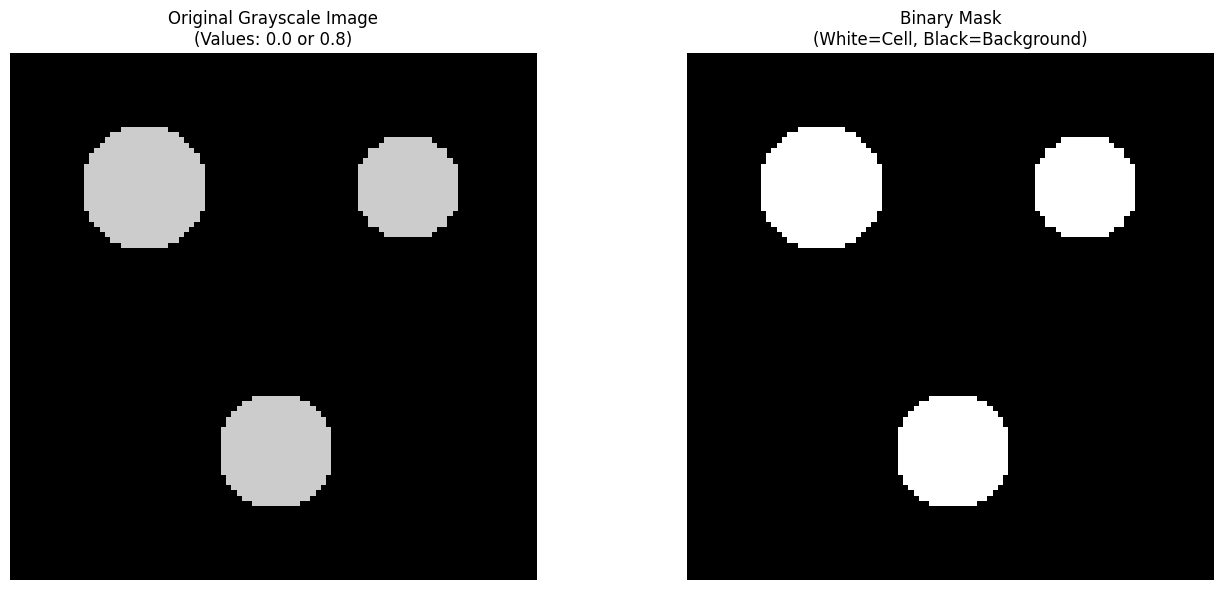

In [ ]:
print("\n" + "="*70)
print("SECTION 2: CREATE BINARY MASK (SEGMENTATION)")
print("="*70)

print("\nWhat is a binary mask?")
print("  A binary mask has only two values: 0 (background) and 1 (object)")
print("  Segmentation converts grayscale image → binary mask")
print("  Logic: If pixel value > 0.5, set to 1. Otherwise, set to 0.")

# Simple threshold: any pixel > 0.5 becomes 1, otherwise 0
binary_mask = (image > 0.5).astype(np.uint8)

print(f"\nResults after thresholding at 0.5:")
print(f"  Foreground pixels (cells): {binary_mask.sum()}")
print(f"  Background pixels: {(binary_mask == 0).sum()}")

# Display original and mask side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Original Grayscale Image\n(Values: 0.0 or 0.8)", fontsize=12)
axes[0].axis('off')

axes[1].imshow(binary_mask, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Binary Mask\n(White=Cell, Black=Background)", fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()